# LLM-as-judge (local Ollama) — BriefMe heading quality

This notebook **evaluates** candidate section headings against passages using a **frozen rubric** in [`briefme.judge_ollama`](../src/briefme/judge_ollama.py). It does **not** replace training a seq2seq model — wire the same `score_heading(...)` call to model outputs later.

## Setup

1. Install [Ollama](https://ollama.com/) and pull a judge model (see next section). Defaults in `.env.example`: `OLLAMA_HOST`, `OLLAMA_MODEL`.
2. Python env: from repo root, `conda env create -f environment.yml`, `conda activate cs474`, `pip install -e ".[dev]"` — see [README.md](../README.md).
3. Hugging Face: copy `.env.example` to `.env` and set `HUGGINGFACE_HUB_TOKEN` for **dev split** scoring.
4. Kernel / cwd: repo root or `notebooks/` — the first code cell adds `src/` when `briefme` is not installed.

**Recommended judge (plan):** `llama3.1:8b` or `llama3.1:8b-instruct-q4_K_M` tag available in your Ollama catalog.

In [7]:
from __future__ import annotations

import os
import sys
from pathlib import Path

from dotenv import load_dotenv


def _repo_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "src" / "briefme").is_dir():
        return cwd
    if (cwd.parent / "src" / "briefme").is_dir():
        return cwd.parent
    return cwd


REPO_ROOT = _repo_root()
SRC_ROOT = REPO_ROOT / "src"

try:
    import briefme as _briefme_check  # noqa: F401
except ImportError:
    if SRC_ROOT.is_dir():
        sys.path.insert(0, str(SRC_ROOT))

# override=True: re-running this cell reloads `.env` changes (dotenv normally does not
# overwrite vars already set in the kernel from a previous run).
load_dotenv(REPO_ROOT / ".env", override=True)

from briefme.data import SPLIT_DEV, load_arg_summ_split_streaming, materialize_head
from briefme.judge_ollama import JUDGE_PROMPT_VERSION, score_heading
from briefme.schema import SOURCE_COLUMN, TARGET_COLUMN

OLLAMA_HOST = os.getenv("OLLAMA_HOST", "http://127.0.0.1:11434")
OLLAMA_MODEL = os.getenv("OLLAMA_MODEL", "llama3.1:8b")
print("JUDGE_PROMPT_VERSION:", JUDGE_PROMPT_VERSION)
print("OLLAMA_HOST:", OLLAMA_HOST)
print("OLLAMA_MODEL:", OLLAMA_MODEL)

JUDGE_PROMPT_VERSION: briefme_heading_judge_v1
OLLAMA_HOST: http://127.0.0.1:11434
OLLAMA_MODEL: llama3.1:8b-instruct-q8_0


## Ollama daemon and model

Start Ollama (`ollama serve` if needed), then pull and smoke-test the judge:

```bash
ollama pull llama3.1:8b
ollama run llama3.1:8b "Say hello in one word."
```

Set `OLLAMA_MODEL` in `.env` to match the tag you pulled.

In [8]:
# Smoke test: three synthetic pairs (requires Ollama reachable).
smoke = [
    (
        "The motion argues that discovery responses were incomplete under Rule 34.",
        "Discovery deficiencies under Rule 34",
        "Gold reference heading",
    ),
    (
        "Plaintiff seeks summary judgment on breach of contract and damages.",
        "Weather forecast for Tuesday",
        None,
    ),
    (
        "The statute of limitations expired before filing; equitable tolling is disputed.",
        "Statute of limitations and equitable tolling",
        "Limitations and tolling",
    ),
]

smoke_rows = []
for passage, cand, ref in smoke:
    out = score_heading(passage, cand, reference_optional=ref, host=OLLAMA_HOST, model=OLLAMA_MODEL)
    smoke_rows.append({"candidate": cand[:60], "score": out["score"], "rationale": out["rationale"]})
    print(out)

{'score': 5, 'rationale': 'The candidate heading accurately and concisely reflects the argument made in the passage.', 'model': 'llama3.1:8b-instruct-q8_0', 'prompt_version': 'briefme_heading_judge_v1', 'cache_key': '8f0cfc54315104bad91cc424e5c9a294a28df6452a56ab3de1544f1f9e16fb81', 'cache_hit': False}
{'score': 1, 'rationale': 'The candidate heading is completely unrelated to the passage, which discusses a legal case.', 'model': 'llama3.1:8b-instruct-q8_0', 'prompt_version': 'briefme_heading_judge_v1', 'cache_key': '90563ba63085744b22043a972e5541b4d2059fde8ba7f7e92a6be5ec268ebf84', 'cache_hit': False}
{'score': 4, 'rationale': 'The candidate heading accurately and specifically describes the main argument or content of the passage.', 'model': 'llama3.1:8b-instruct-q8_0', 'prompt_version': 'briefme_heading_judge_v1', 'cache_key': 'a3fa30394bd4328581db36fd896d72e86e1934a3af3f388968fce478cd28e0ad', 'cache_hit': False}


Scored 30 dev rows; mean score=5.00


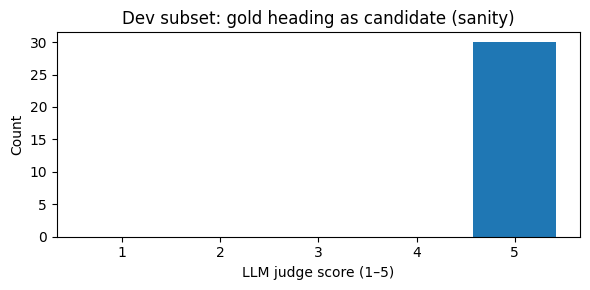

In [9]:
import matplotlib.pyplot as plt

# Dev subset: sanity = score gold heading as candidate (expects mostly high scores).
DEV_N = 30
CACHE_PATH = REPO_ROOT / "artifacts" / "llm_judge_runs" / "dev_llm_judge.jsonl"

if not (os.getenv("HUGGINGFACE_HUB_TOKEN") or os.getenv("HF_TOKEN")):
    raise RuntimeError(
        "Set HUGGINGFACE_HUB_TOKEN (or HF_TOKEN) in .env to load the dev split from the Hub."
    )

dev_ds = materialize_head(load_arg_summ_split_streaming(SPLIT_DEV), DEV_N)
results = []
for i, row in enumerate(dev_ds):
    passage = row[SOURCE_COLUMN]
    gold = row[TARGET_COLUMN]
    out = score_heading(
        passage,
        gold,
        reference_optional=gold,
        host=OLLAMA_HOST,
        model=OLLAMA_MODEL,
        cache_path=CACHE_PATH,
    )
    results.append(
        {
            "idx": i,
            "score": out["score"],
            "rationale": out["rationale"],
            "cache_hit": out.get("cache_hit", False),
            "gold": gold,
            "passage_preview": (passage[:240] + "…") if len(passage) > 240 else passage,
        }
    )

scores = [r["score"] for r in results]
print(f"Scored {len(results)} dev rows; mean score={sum(scores)/len(scores):.2f}")

plt.figure(figsize=(6, 3))
plt.hist(scores, bins=[1, 2, 3, 4, 5, 6], align="left", rwidth=0.85)
plt.xlabel("LLM judge score (1–5)")
plt.ylabel("Count")
plt.title("Dev subset: gold heading as candidate (sanity)")
plt.xticks(range(1, 6))
plt.tight_layout()
plt.show()

In [10]:
# Best and worst rows (by score)
ranked = sorted(results, key=lambda r: r["score"])
worst = ranked[:5]
best = ranked[-5:][::-1]

print("--- Lowest scores ---")
for r in worst:
    print(r["score"], "|", r["gold"][:120])
    print(" ", r["rationale"])

print("--- Highest scores ---")
for r in best:
    print(r["score"], "|", r["gold"][:120])
    print(" ", r["rationale"])

--- Lowest scores ---
5 | Legislatures may reasonably regulate firearms to protect public safety
  The candidate heading accurately and concisely captures the main argument of the passage.
5 | Legislatures have broad authority to regulate firearms
  The candidate heading accurately and concisely reflects the passage's argument that legislatures have a long history of regulating firearms and that such regulation is consistent with the Second Amendment.
5 | A court should uphold an arms regulation if it is validated by text, history, and tradition or if it satisfies intermedi
  The candidate heading accurately and concisely reflects the passage's argument.
5 | Federal law illustrates the types of regulations that legislatures may constitutionally adopt
  The candidate heading accurately and concisely reflects the passage's argument about the types of regulations that are constitutional under the Second Amendment.
5 | New York's licensing regime permissibly regulates the carrying of handg

## Next steps

- Replace `gold` as the candidate with **model-generated headings** once you have predictions; keep `reference_optional` as the gold string for calibration.
- Report **ROUGE / exact match** alongside LLM scores (see `planning/north_star_plan.md`).
- If the judge returns non-JSON output often, tighten the prompt once, log `prompt_version`, or try another local model (e.g. Qwen2.5 instruct) with the **same** frozen rubric text for fair comparison.